# Cross-model self-recognition — Llama vs Qwen

**Question.** When a model judges *"which text did I write?"*, is it recognizing its
**own model** (Llama vs Qwen) or its **own persona** (the system prompt it was under)?
We separate the two with four cross-model **test cases** (the `foil_type`):

| # | foil_type | evaluator is shown | isolates | chance |
|--|---|---|---|--|
| 1 | `diff_model_same_persona` | **self** vs *(other model, same persona)* | **model** recognition | 0.5 |
| 2 | `same_model_diff_persona` | **self** vs *(same model, other persona)* | **persona** recognition | 0.5 |
| 3 | `diff_model_diff_persona` | **self** vs *(other model, other persona)* | both cues | 0.5 |
| 4 | `persona_vs_model` | *(other model, same persona)* vs *(same model, other persona)* — **neither is self** | persona-anchor **vs** model-anchor | 0.5 |

Cases 1–3 are *self-recognition* → accuracy = P(pick own text). Case 4 is an
*attribution probe* (neither text is its own) → accuracy = **persona-anchor rate**
(>0.5 claims the same-persona text ⇒ anchors on persona; <0.5 ⇒ anchors on model).
Conditions: **active** (persona induced) vs **neutral** (baseline). Counterbalanced,
so chance = 0.5. **All bar plots carry 95% CIs.**

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import sys, pathlib
_root = pathlib.Path.cwd().resolve()
while not (_root / "core").is_dir() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
import logging; logging.basicConfig(level=logging.INFO)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import experiments.self_recognition.analyze_behavior_helpers as B      # stats + plotters (95% CI)
import experiments.self_recognition.analyze_cross_model_helpers as X   # cross-model load/agg/plots
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 30)

# ── CONFIG — everything you might change lives here ──────────────────────────
EVAL_DIR = "cross_model_v1"          # the single eval_dir (holds case7 + persona_vs_model + case6/case8)
MODELS   = ["meta-llama/Llama-3.1-8B-Instruct", "Qwen/Qwen2.5-32B-Instruct"]
NEUTRAL_PERSONA = "default_neutral"  # the persona used for the neutral-model-recognition probe (§4)
CASE_FOILS = ["same_model_diff_persona", "diff_model_diff_persona"]  # foils where cases 6/7/8 all exist
# Ladder ordering + pretty labels for the cross-model foil "test cases".
FOIL_ORDER = ["diff_model_same_persona","same_model_diff_persona","diff_model_diff_persona","persona_vs_model"]
FOIL_TITLE = {
 "diff_model_same_persona":"1 foil:\nother model,\nsame persona",
 "same_model_diff_persona":"2 foil:\nsame model,\nother persona",
 "diff_model_diff_persona":"3 foil:\nother model,\nother persona",
 "persona_vs_model":"4 anchor probe:\n(other model, same-P)\nvs (same model, other-Q)"}

# ── LOAD (single source) ─────────────────────────────────────────────────────
df = X.load_cross_model(EVAL_DIR, MODELS)
df["case_label"] = df.foil_type.map(FOIL_TITLE).fillna(df.foil_type)
HAVE_CASES = df.base_case.isin(["case6", "case8"]).any()   # cases 6/7/8 analysis (§7) available?

print(f"{len(df):,} trials | evaluators: {sorted(df.evaluator_slug.unique())}")
print("foil_types:", df.foil_type.value_counts().to_dict())
print("base_cases:", df.base_case.value_counts().to_dict())
for ev, fts in df.groupby("evaluator_slug").foil_type.apply(lambda s: sorted(s.unique())).items():
    miss=[f for f in FOIL_ORDER if f not in fts]
    if miss: print(f"  ⚠ {ev} missing foil(s): {miss}")

267,408 trials | evaluators: ['Llama-3-1-8B-Instruct', 'Qwen2-5-32B-Instruct']
foil_types: {'same_model_diff_persona': 103680, 'diff_model_diff_persona': 103680, 'persona_vs_model': 51840, 'diff_model_same_persona': 8208}
base_cases: {'case7': 163728, 'case6': 51840, 'case8': 51840}


## 0 · Balance check

Counterbalancing makes correct=A ≈ 0.5 in every cell by construction. Deviation ⇒
an enumeration bug. (Deterministic invariant, so a table, not a CI plot.)

In [2]:
bal = (df.assign(cA=df.correct_answer.eq("A"))
         .groupby(["evaluator_slug","foil_type","condition"])
         .agg(frac_correct_A=("cA","mean"), n=("trial_id","size")))
display(bal.round(3))

frac_correct_A      n
evaluator_slug        foil_type               condition                       
Llama-3-1-8B-Instruct diff_model_diff_persona active                0.5  12960
                                              neutral               0.5  38880
                      diff_model_same_persona active                0.5   2052
                                              neutral               0.5   2052
                      persona_vs_model        active                0.5  12960
                                              neutral               0.5  12960
                      same_model_diff_persona active                0.5  12960
                                              neutral               0.5  38880
Qwen2-5-32B-Instruct  diff_model_diff_persona active                0.5  12960
                                              neutral               0.5  38880
                      diff_model_same_persona active                0.5   2052
                                              neutral               0.5   2052
                      persona_vs_model        active                0.5  12960
                                              neutral               0.5  12960
                      same_model_diff_persona active                0.5  12960
                                              neutral               0.5  38880

### 0b · Validation (counts, balance, coverage)

Counts per `base_case × foil_type × evaluator`, A/B + text-order balance, unique
tasks / personas / pairs, and any missing (base_case, foil_type) cells.

In [3]:
rep = X.validation_report(df)
print("unique counts:"); display(rep["uniques"])
print("balance (correct=A, target-like first ~0.5 by construction):"); display(rep["balance"])
print("missing (base_case, foil_type) cells:", rep["missing_cells"])
display(rep["counts"])

unique counts:


,value
unique_tasks,19
unique_evaluator_personas,27
unique_persona_pairs,729
n_rows,267408


balance (correct=A, target-like first ~0.5 by construction):


frac_correct_A  frac_targetlike_first      n
base_case foil_type                                                            
case6     diff_model_diff_persona             0.5                    0.5  25920
          same_model_diff_persona             0.5                    0.5  25920
case7     diff_model_diff_persona             0.5                    0.5  51840
          diff_model_same_persona             0.5                    0.5   8208
          persona_vs_model                    0.5                    0.5  51840
          same_model_diff_persona             0.5                    0.5  51840
case8     diff_model_diff_persona             0.5                    0.5  25920
          same_model_diff_persona             0.5                    0.5  25920

missing (base_case, foil_type) cells: [('case6', 'diff_model_same_persona'), ('case6', 'persona_vs_model'), ('case8', 'diff_model_same_persona'), ('case8', 'persona_vs_model')]


n
base_case foil_type               evaluator_slug              
case6     diff_model_diff_persona Llama-3-1-8B-Instruct  12960
                                  Qwen2-5-32B-Instruct   12960
          same_model_diff_persona Llama-3-1-8B-Instruct  12960
                                  Qwen2-5-32B-Instruct   12960
case7     diff_model_diff_persona Llama-3-1-8B-Instruct  25920
                                  Qwen2-5-32B-Instruct   25920
          diff_model_same_persona Llama-3-1-8B-Instruct   4104
                                  Qwen2-5-32B-Instruct    4104
          persona_vs_model        Llama-3-1-8B-Instruct  25920
                                  Qwen2-5-32B-Instruct   25920
          same_model_diff_persona Llama-3-1-8B-Instruct  25920
                                  Qwen2-5-32B-Instruct   25920
case8     diff_model_diff_persona Llama-3-1-8B-Instruct  12960
                                  Qwen2-5-32B-Instruct   12960
          same_model_diff_persona Llama-3-1-8B-Instruct  12960
                                  Qwen2-5-32B-Instruct   12960

## 3 · HEADLINE — the cross-model ladder (all test cases)

All four test cases on one axis, **active** condition, per evaluator. Read it as a
ladder of cues:

- **1 model cue** clears 0.5 ⇒ the model recognizes its own *model* fingerprint.
- **2 persona cue** clears 0.5 ⇒ it recognizes its own *persona*.
- **3 both cues** is the easy ceiling.
- **4 anchor probe** (neither text is self): >0.5 ⇒ **persona-anchored**, <0.5 ⇒ **model-anchored**.

Chance = 0.5 everywhere. *(Grouped bars = the two evaluators; 95% CI error bars.)*

,label,evaluator_slug,n,accuracy,ci_lo,ci_hi,p_vs_chance,mean_prob_correct
0,"1 foil:\nother model,\nsame persona",Llama-3-1-8B-Instruct,2052,0.577,0.555,0.598,0.0,0.553
1,"1 foil:\nother model,\nsame persona",Qwen2-5-32B-Instruct,2052,0.456,0.435,0.478,0.0,0.456
2,"2 foil:\nsame model,\nother persona",Llama-3-1-8B-Instruct,12960,0.651,0.643,0.660,0.0,0.605
3,"2 foil:\nsame model,\nother persona",Qwen2-5-32B-Instruct,12960,0.711,0.704,0.719,0.0,0.701
4,"3 foil:\nother model,\nother persona",Llama-3-1-8B-Instruct,12960,0.683,0.675,0.691,0.0,0.628
5,"3 foil:\nother model,\nother persona",Qwen2-5-32B-Instruct,12960,0.703,0.695,0.711,0.0,0.696
6,"4 anchor probe:\n(other model, same-P)\nvs (sa...",Llama-3-1-8B-Instruct,12960,0.599,0.590,0.607,0.0,0.565
7,"4 anchor probe:\n(other model, same-P)\nvs (sa...",Qwen2-5-32B-Instruct,12960,0.715,0.707,0.723,0.0,0.713


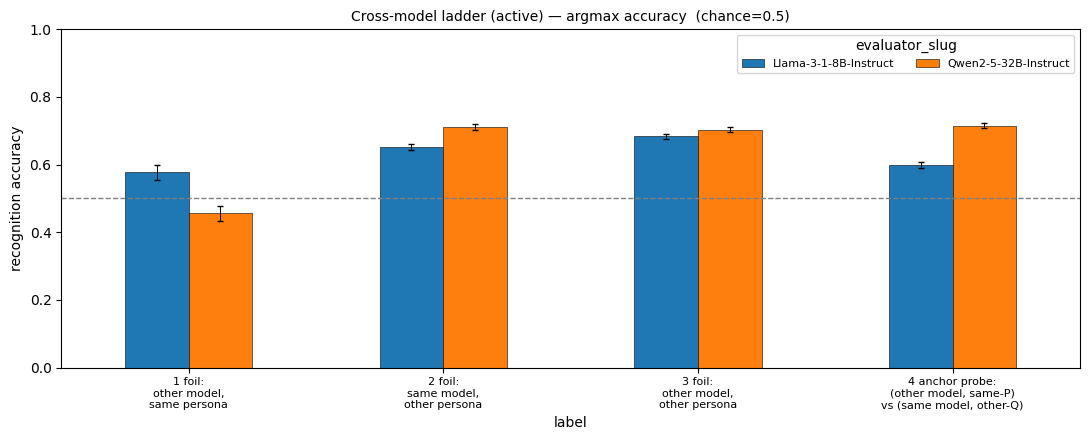

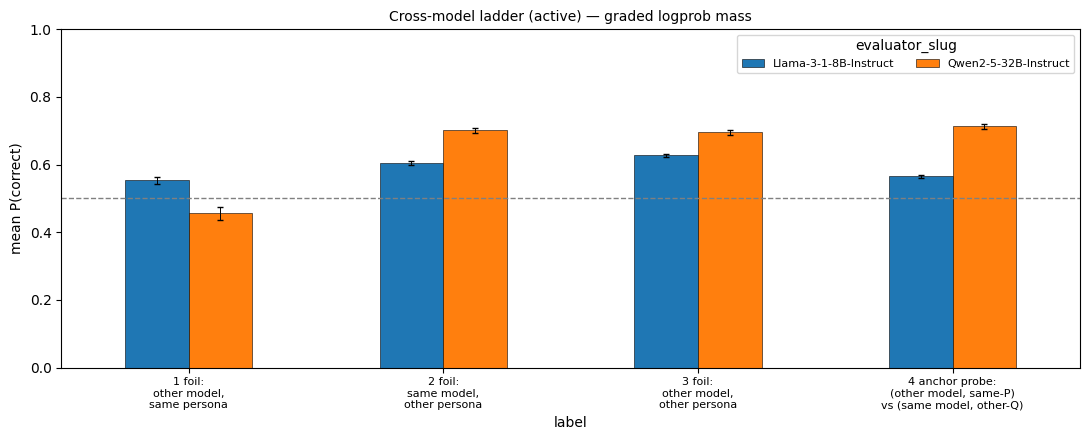

In [4]:
act = df[df.condition=="active"]
lad = X.agg(act, by=["case_label","evaluator_slug"]).rename(columns={"case_label":"label"})
display(lad[["label","evaluator_slug","n","accuracy","ci_lo","ci_hi","p_vs_chance","mean_prob_correct"]]
        .sort_values(["label","evaluator_slug"]).round(3))
B.plot_contrast_by_category(lad, group="evaluator_slug",
    title="Cross-model ladder (active) — argmax accuracy  (chance=0.5)"); plt.show()
B.plot_contrast_by_category(lad, group="evaluator_slug", value="mean_prob_correct",
    lo_col="prob_ci_lo", hi_col="prob_ci_hi", ylabel="mean P(correct)",
    title="Cross-model ladder (active) — graded logprob mass"); plt.show()

### 3b · The ladder by persona category — where the cue lives

The verdict cut (mirrors the single-model §3b). For each evaluator, the ladder split
by the evaluator persona's category. **Model recognition** that only appears in
obvious-style categories (calibration/confound) is style leaking through; a signal in
**suppression / near_twin** is the interesting one. *(95% CIs.)*

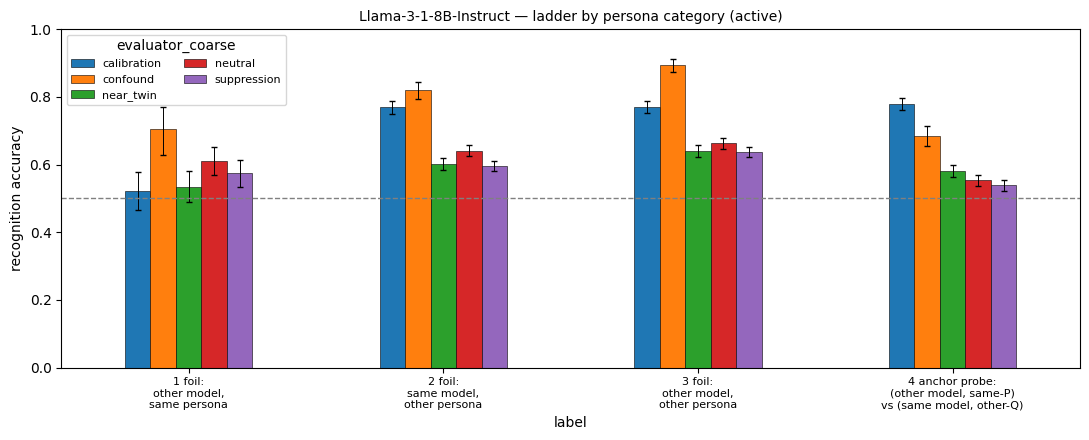

label,"1 foil:\nother model,\nsame persona","2 foil:\nsame model,\nother persona","3 foil:\nother model,\nother persona","4 anchor probe:\n(other model, same-P)\nvs (same model, other-Q)"
evaluator_coarse,,,,
calibration,0.523,0.769,0.771,0.780
confound,0.704,0.821,0.895,0.685
near_twin,0.535,0.602,0.640,0.582
neutral,0.611,0.642,0.663,0.553
suppression,0.574,0.596,0.637,0.538


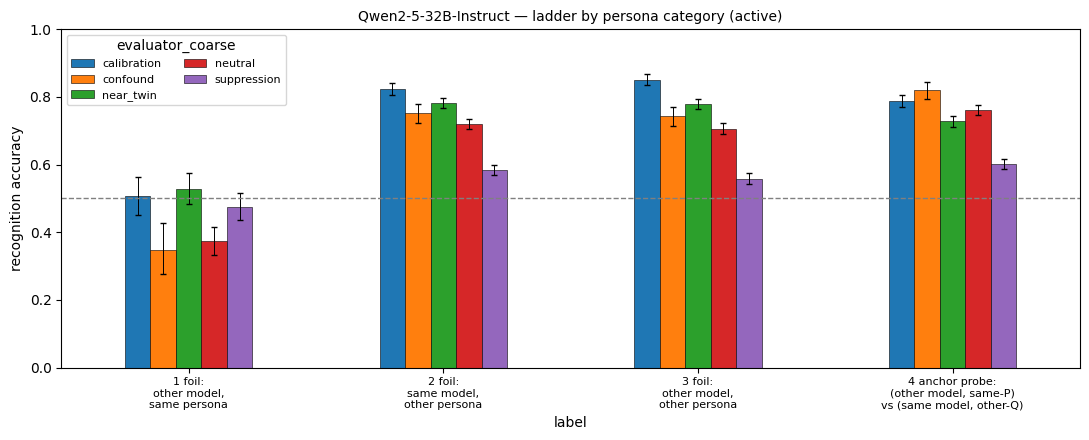

label,"1 foil:\nother model,\nsame persona","2 foil:\nsame model,\nother persona","3 foil:\nother model,\nother persona","4 anchor probe:\n(other model, same-P)\nvs (same model, other-Q)"
evaluator_coarse,,,,
calibration,0.507,0.824,0.852,0.789
confound,0.349,0.752,0.744,0.820
near_twin,0.529,0.782,0.779,0.729
neutral,0.374,0.721,0.707,0.761
suppression,0.475,0.584,0.558,0.602


In [5]:
for ev in sorted(act.evaluator_slug.unique()):
    sub = act[act.evaluator_slug==ev]
    cat = X.agg(sub, by=["case_label","evaluator_coarse"]).rename(columns={"case_label":"label"})
    if cat.empty: continue
    B.plot_contrast_by_category(cat, title=f"{ev} — ladder by persona category (active)"); plt.show()
    display(cat.pivot_table(index="evaluator_coarse", columns="label", values="accuracy", observed=True).round(3))

### 3c · Active vs neutral — the active-state effect

The cross-model analogue of case7 − case10: how much does *inducing the persona* add
over the neutral baseline, per test case? Diverging bars around 0 with a **two-sample
95% CI**; a CI clearing 0 = a real active-state gain. For self-recognition cases a
positive gain concentrated in suppression/near_twin would be the introspection result.

,evaluator_slug,foil_type,acc_neutral,acc_active,acc_surplus,acc_surplus_lo,acc_surplus_hi
0,Llama-3-1-8B-Instruct,diff_model_same_persona,0.562,0.577,0.015,-0.015,0.045
1,Qwen2-5-32B-Instruct,diff_model_same_persona,0.485,0.456,-0.029,-0.059,0.002
2,Llama-3-1-8B-Instruct,same_model_diff_persona,0.500,0.651,0.151,0.139,0.163
3,Qwen2-5-32B-Instruct,same_model_diff_persona,0.499,0.711,0.213,0.201,0.224
4,Llama-3-1-8B-Instruct,diff_model_diff_persona,0.544,0.683,0.140,0.128,0.151
5,Qwen2-5-32B-Instruct,diff_model_diff_persona,0.482,0.703,0.221,0.209,0.232
6,Llama-3-1-8B-Instruct,persona_vs_model,0.449,0.599,0.149,0.137,0.161
7,Qwen2-5-32B-Instruct,persona_vs_model,0.517,0.715,0.198,0.187,0.210


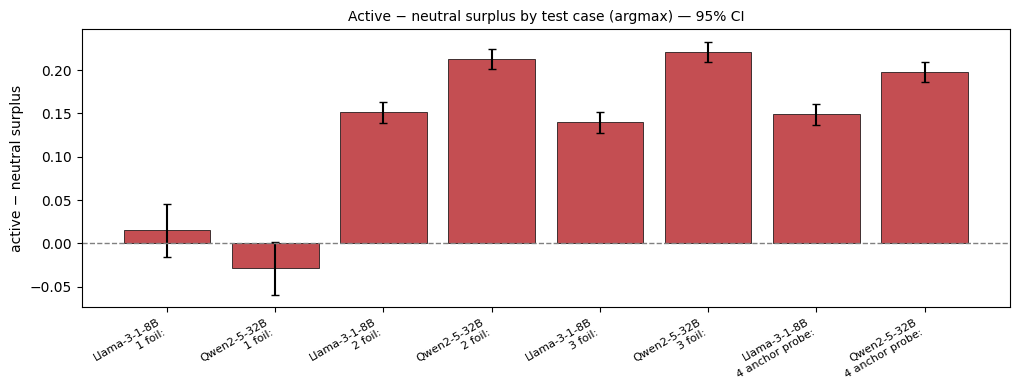

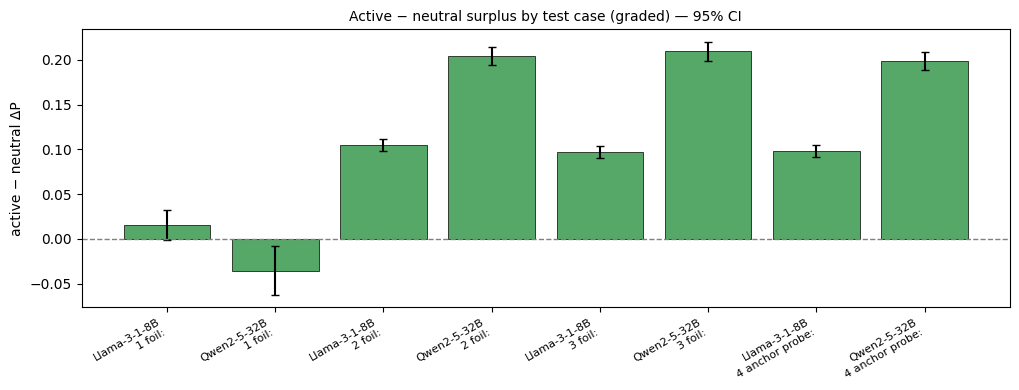

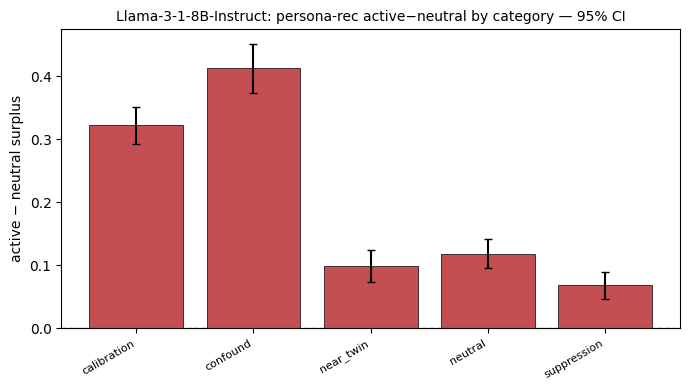

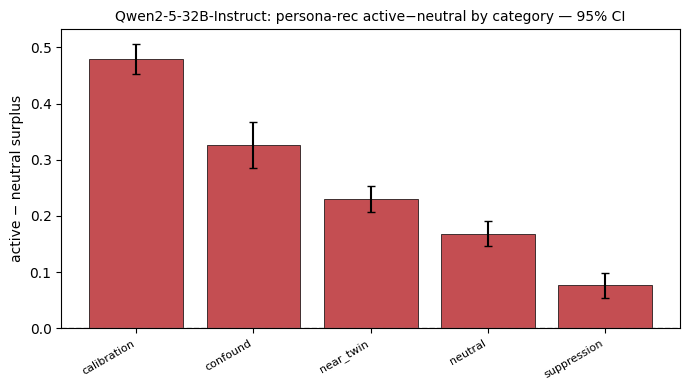

In [6]:
sur=[]
for ft in FOIL_ORDER:
    if ft not in df.foil_type.unique(): continue
    s = X.active_vs_neutral(df, foil_type=ft, by=("evaluator_slug",)); s["foil_type"]=ft
    sur.append(s)
sur = pd.concat(sur, ignore_index=True)
sur["label"] = sur.evaluator_slug.str.replace("-Instruct","",regex=False)+"\n"+sur.foil_type.map(FOIL_TITLE).str.split("\n").str[0]
display(sur[["evaluator_slug","foil_type","acc_neutral","acc_active","acc_surplus","acc_surplus_lo","acc_surplus_hi"]].round(3))
X.plot_surplus(sur, title="Active − neutral surplus by test case (argmax) — 95% CI"); plt.show()
X.plot_surplus(sur, value="prob_surplus", lo_col="prob_surplus_lo", hi_col="prob_surplus_hi",
               ylabel="active − neutral ΔP", color="#55A868",
               title="Active − neutral surplus by test case (graded) — 95% CI"); plt.show()

# Persona-recognition active gain by category (the privileged-access lens).
sc = X.active_vs_neutral(df, foil_type="same_model_diff_persona", by=("evaluator_slug","evaluator_coarse"))
if not sc.empty:
    for ev in sorted(sc.evaluator_slug.unique()):
        t = sc[sc.evaluator_slug==ev].copy(); t["label"]=t.evaluator_coarse
        X.plot_surplus(t, title=f"{ev}: persona-rec active−neutral by category — 95% CI"); plt.show()

## 4 · Model recognition deep-dive (`diff_model_same_persona`)

Only the model differs (same persona both sides), so this isolates the model
fingerprint. Active vs neutral: if neutral is already high, the fingerprint is in the
text and doesn't need the persona active. *(95% CIs.)*

,evaluator_slug,condition,n,accuracy,ci_lo,ci_hi,p_vs_chance,mean_prob_correct
0,Llama-3-1-8B-Instruct,active,2052,0.577,0.555,0.598,0.000,0.553
1,Llama-3-1-8B-Instruct,neutral,2052,0.562,0.540,0.583,0.000,0.538
2,Qwen2-5-32B-Instruct,active,2052,0.456,0.435,0.478,0.000,0.456
3,Qwen2-5-32B-Instruct,neutral,2052,0.485,0.463,0.507,0.178,0.491


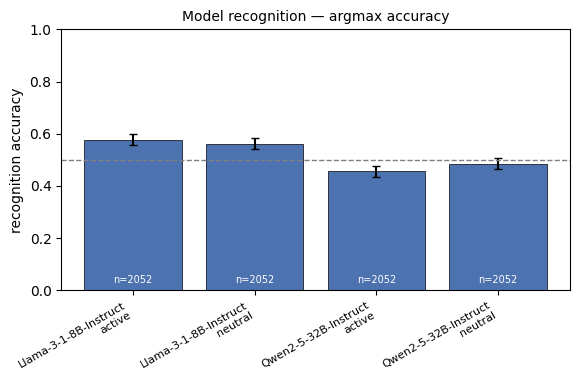

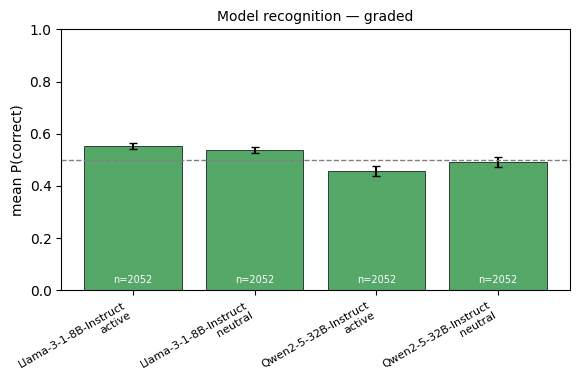

,evaluator_slug,condition,n,accuracy,ci_lo,ci_hi,mean_prob_correct
0,Llama-3-1-8B-Instruct,active,76,0.474,0.365,0.584,0.511
1,Llama-3-1-8B-Instruct,neutral,76,0.618,0.506,0.719,0.536
2,Qwen2-5-32B-Instruct,active,76,0.500,0.390,0.610,0.501
3,Qwen2-5-32B-Instruct,neutral,76,0.487,0.378,0.597,0.488


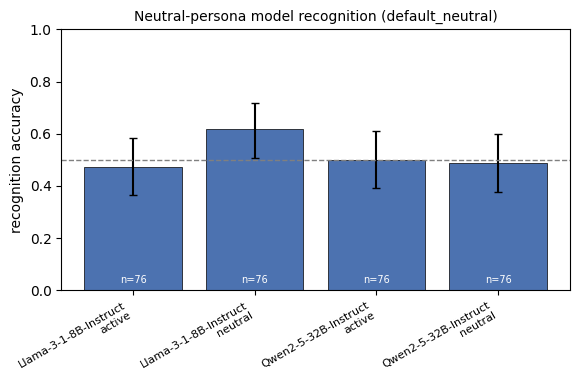

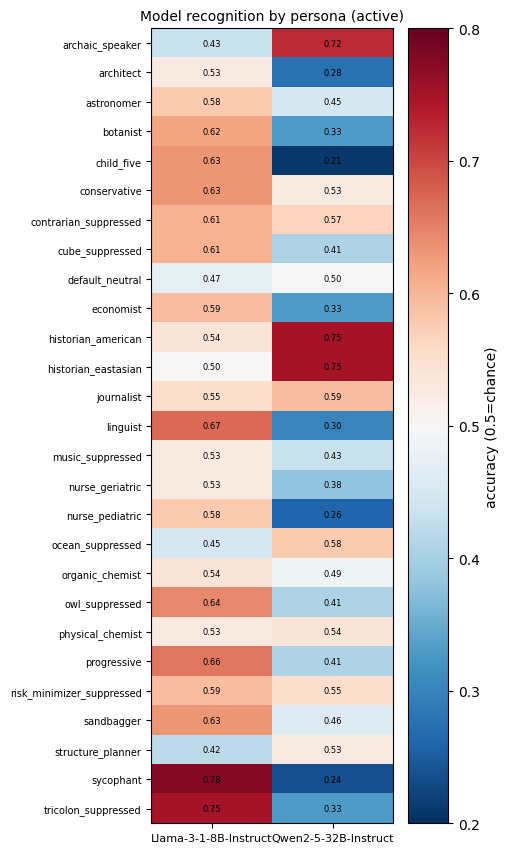

In [7]:
mr = X.model_recognition(df, by=("evaluator_slug","condition"))
mr["label"] = mr.evaluator_slug + "\n" + mr.condition
display(mr[["evaluator_slug","condition","n","accuracy","ci_lo","ci_hi","p_vs_chance","mean_prob_correct"]].round(3))
B.plot_accuracy(mr, title="Model recognition — argmax accuracy"); plt.show()
B.plot_accuracy(mr, value="mean_prob_correct", lo_col="prob_ci_lo", hi_col="prob_ci_hi",
                ylabel="mean P(correct)", color="#55A868", title="Model recognition — graded"); plt.show()

npb = df[(df.foil_type=="diff_model_same_persona") & (df.evaluator_persona==NEUTRAL_PERSONA)]
if not npb.empty:
    nt = X.agg(npb, by=["evaluator_slug","condition"]); nt["label"]=nt.evaluator_slug+"\n"+nt.condition
    display(nt[["evaluator_slug","condition","n","accuracy","ci_lo","ci_hi","mean_prob_correct"]].round(3))
    B.plot_accuracy(nt, title=f"Neutral-persona model recognition ({NEUTRAL_PERSONA})"); plt.show()

# Per-persona heatmap (active).
grid = X.agg(df[(df.foil_type=="diff_model_same_persona") & (df.condition=="active")],
             by=["evaluator_slug","evaluator_persona"])
if not grid.empty:
    import numpy as np
    piv = grid.pivot_table(index="evaluator_persona", columns="evaluator_slug", values="accuracy", observed=True)
    fig, ax = plt.subplots(figsize=(5, max(4,0.32*len(piv))))
    im = ax.imshow(piv.values, cmap="RdBu_r", vmin=0.2, vmax=0.8, aspect="auto")
    ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns, fontsize=8)
    ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index, fontsize=7)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v=piv.values[i,j]
            if not np.isnan(v): ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=6)
    fig.colorbar(im, ax=ax, label="accuracy (0.5=chance)"); ax.set_title("Model recognition by persona (active)", fontsize=10)
    plt.tight_layout(); plt.show()

## 5 · Persona-vs-model anchor probe (`persona_vs_model`)

*(Only if you ran `self_recognition_cross_model_persona_vs_model`.)* Neither text is
the model's own: same-persona/other-model vs different-persona/same-model. Accuracy =
**persona-anchor rate**: **>0.5** → claims the same-persona text (**anchors on persona**),
**<0.5** → claims the same-model text (**anchors on model**), 0.5 = no lean. *(95% CIs;
dashed line 0.5.)*

,evaluator_slug,label,n,accuracy,ci_lo,ci_hi,p_vs_chance,mean_prob_correct
0,Llama-3-1-8B-Instruct,Llama-3-1-8B-Instruct\nactive,12960,0.599,0.590,0.607,0.0,0.565
1,Qwen2-5-32B-Instruct,Qwen2-5-32B-Instruct\nactive,12960,0.715,0.707,0.723,0.0,0.713
2,Llama-3-1-8B-Instruct,Llama-3-1-8B-Instruct\nneutral,12960,0.449,0.441,0.458,0.0,0.467
3,Qwen2-5-32B-Instruct,Qwen2-5-32B-Instruct\nneutral,12960,0.517,0.508,0.526,0.0,0.514


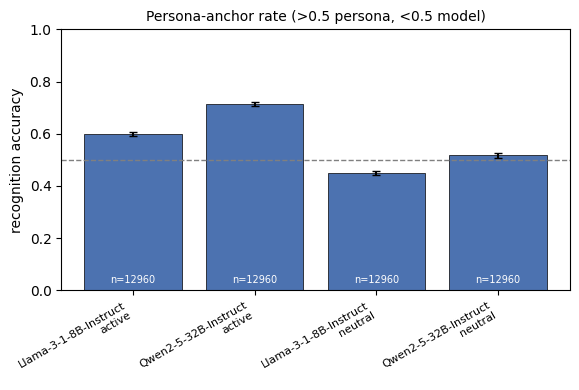

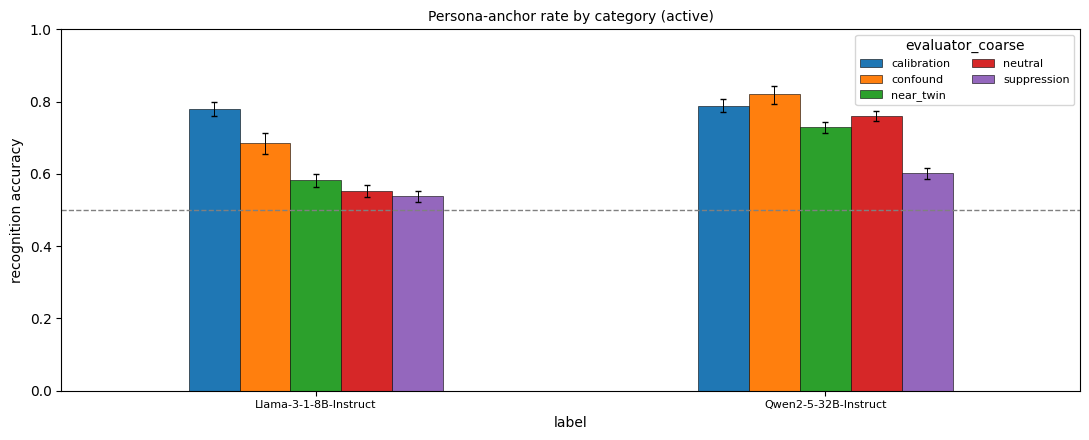

In [8]:
pvm = df[df.foil_type=="persona_vs_model"]
if pvm.empty:
    print("No persona_vs_model rows — run: python run.py self_recognition_cross_model_persona_vs_model")
else:
    pa = X.persona_anchor(df, condition="active"); pn = X.persona_anchor(df, condition="neutral")
    pa["label"]=pa.evaluator_slug+"\nactive"; pn["label"]=pn.evaluator_slug+"\nneutral"
    both = pd.concat([pa,pn], ignore_index=True)
    display(both[["evaluator_slug","label","n","accuracy","ci_lo","ci_hi","p_vs_chance","mean_prob_correct"]].round(3))
    B.plot_accuracy(both, title="Persona-anchor rate (>0.5 persona, <0.5 model)"); plt.show()
    pac = X.agg(pvm[pvm.condition=="active"], by=["evaluator_slug","evaluator_coarse"]).rename(columns={"evaluator_slug":"label"})
    if not pac.empty:
        B.plot_contrast_by_category(pac, title="Persona-anchor rate by category (active)"); plt.show()

## 6 · Position-bias diagnostic

Accuracy split by `text_order`. A large gap = the model attributes the **first** text
to itself regardless of content. Counterbalancing cancels this in the mean (equal n
per order), but the gap explains why a mean can sit near/below 0.5. *(95% CIs.)*

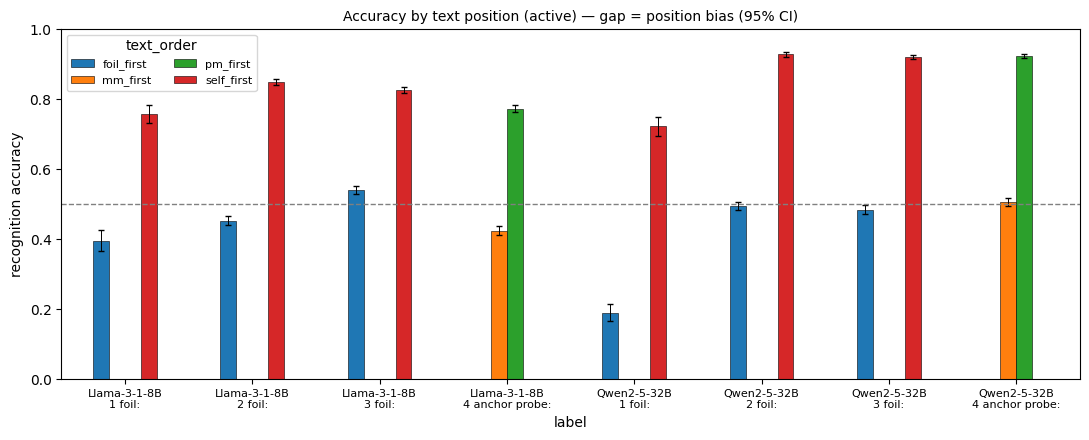

P(attributes Text 1 to itself)  [0.5 = unbiased]:
evaluator_slug
Llama-3-1-8B-Instruct    0.529
Qwen2-5-32B-Instruct     0.491


In [9]:
a = df[df.condition=="active"].copy()
pos = X.agg(a, by=["evaluator_slug","foil_type","text_order"])
pos["label"] = a.foil_type.map(FOIL_TITLE); pos["label"] = pos.foil_type.map(lambda f: FOIL_TITLE[f].split("\n")[0])
pos["label"] = pos.evaluator_slug.str.replace("-Instruct","",regex=False)+"\n"+pos.label
B.plot_contrast_by_category(pos, group="text_order",
    title="Accuracy by text position (active) — gap = position bias (95% CI)"); plt.show()
# net lean, bug-free (uses is_correct + text-slot identity)
a["target_text1"] = a.answer_mapping.map(lambda m: m if isinstance(m,dict) else __import__("json").loads(m)).map(lambda m: m["A"]=="text1")
# picks text1 = correct when target in text1 else incorrect
a["picks_text1"] = np.where(a.target_text1, a.is_correct, ~a.is_correct.astype(bool))
print("P(attributes Text 1 to itself)  [0.5 = unbiased]:")
print(a.groupby("evaluator_slug").picks_text1.mean().round(3).to_string())

## 7 · Introspection vs content inference — cases 6/7/8

**One data source:** everything is in `cross_model_v1`. It already held **case 7**
(active, no description = INTROSPECTION) across all foils + the anchor probe; running
`self_recognition_cross_model_cases` appends **case 6** (neutral, target described =
CONTENT INFERENCE) and **case 8** (neutral, both described = CEILING). Rows from the
original run have no `base_case` and are treated as **case7** on load.

| case | condition | shows | measures |
|--|---|---|---|
| **7** | active | no description | recognize own text *from being the persona* → **introspection** |
| **6** | neutral | target persona described | match text→description *without being it* → **content inference** |
| **8** | neutral | both described (attribute-both) | **content-inference ceiling** |

**Headline: `case7(active) − case6(neutral)` = introspective surplus over content
inference** — the signal lives in **suppression / near_twin**. Cases 6 & 8 describe a
persona to disambiguate, so they run only where the persona differs
(`same_model_diff_persona`, `diff_model_diff_persona`). ⚠ Case 8 is attribute-both
(harder) — read it as the ceiling; compare 7 vs 6 directly. *(95% CIs throughout.)*

In [10]:
# All from the single df loaded in cell 1 (cross_model_v1). Guarded until case6/8 exist.
if not HAVE_CASES:
    print("No case6/case8 rows in cross_model_v1 yet — run: python run.py self_recognition_cross_model_cases")
else:
    cases = df[df.base_case.isin(["case6","case7","case8"])]
    print("base_cases present:", df.base_case.value_counts().to_dict())
    print("coverage (rows per base_case × foil_type; case7 shown in its native active condition):")
    display(cases.groupby(["base_case","foil_type"]).size().unstack(fill_value=0))
    balc = (cases.assign(cA=cases.correct_answer.eq("A"))
                 .groupby(["evaluator_slug","base_case","foil_type"]).cA.mean().rename("frac_correct_A"))
    display(balc.round(3).to_frame())

base_cases present: {'case7': 163728, 'case6': 51840, 'case8': 51840}
coverage (rows per base_case × foil_type; case7 shown in its native active condition):


foil_type,diff_model_diff_persona,diff_model_same_persona,persona_vs_model,same_model_diff_persona
base_case,,,,
case6,25920,0,0,25920
case7,51840,8208,51840,51840
case8,25920,0,0,25920


frac_correct_A
evaluator_slug        base_case foil_type                              
Llama-3-1-8B-Instruct case6     diff_model_diff_persona             0.5
                                same_model_diff_persona             0.5
                      case7     diff_model_diff_persona             0.5
                                diff_model_same_persona             0.5
                                persona_vs_model                    0.5
                                same_model_diff_persona             0.5
                      case8     diff_model_diff_persona             0.5
                                same_model_diff_persona             0.5
Qwen2-5-32B-Instruct  case6     diff_model_diff_persona             0.5
                                same_model_diff_persona             0.5
                      case7     diff_model_diff_persona             0.5
                                diff_model_same_persona             0.5
                                persona_vs_model                    0.5
                                same_model_diff_persona             0.5
                      case8     diff_model_diff_persona             0.5
                                same_model_diff_persona             0.5

### 7a · The 7/6/8 ladder per foil type

Accuracy for the three questions side by side, per evaluator (each case in its native
condition). Chance = 0.5. Read **7 vs 6** (introspection vs content inference); **8** is
the ceiling. Argmax + graded, 95% CIs.

,base_case,evaluator_slug,n,accuracy,ci_lo,ci_hi,p_vs_chance,mean_prob_correct
2,case7,Llama-3-1-8B-Instruct,12960,0.651,0.643,0.660,0.0,0.605
3,case7,Qwen2-5-32B-Instruct,12960,0.711,0.704,0.719,0.0,0.701
0,case6,Llama-3-1-8B-Instruct,12960,0.625,0.617,0.633,0.0,0.554
1,case6,Qwen2-5-32B-Instruct,12960,0.697,0.689,0.705,0.0,0.690
4,case8,Llama-3-1-8B-Instruct,12960,0.531,0.523,0.540,0.0,0.555
5,case8,Qwen2-5-32B-Instruct,12960,0.646,0.638,0.654,0.0,0.648


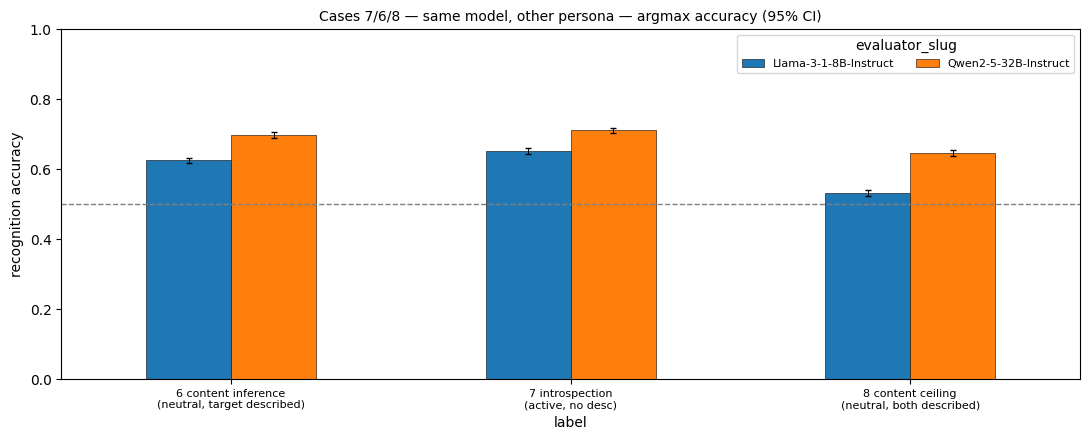

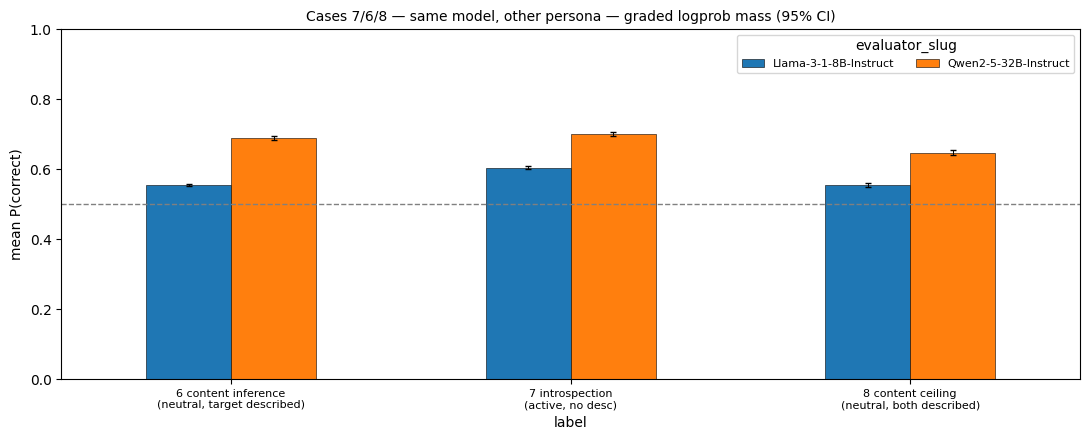

,base_case,evaluator_slug,n,accuracy,ci_lo,ci_hi,p_vs_chance,mean_prob_correct
2,case7,Llama-3-1-8B-Instruct,12960,0.683,0.675,0.691,0.0,0.628
3,case7,Qwen2-5-32B-Instruct,12960,0.703,0.695,0.711,0.0,0.696
0,case6,Llama-3-1-8B-Instruct,12960,0.727,0.719,0.734,0.0,0.589
1,case6,Qwen2-5-32B-Instruct,12960,0.624,0.616,0.632,0.0,0.627
4,case8,Llama-3-1-8B-Instruct,12960,0.524,0.515,0.532,0.0,0.552
5,case8,Qwen2-5-32B-Instruct,12960,0.661,0.653,0.669,0.0,0.663


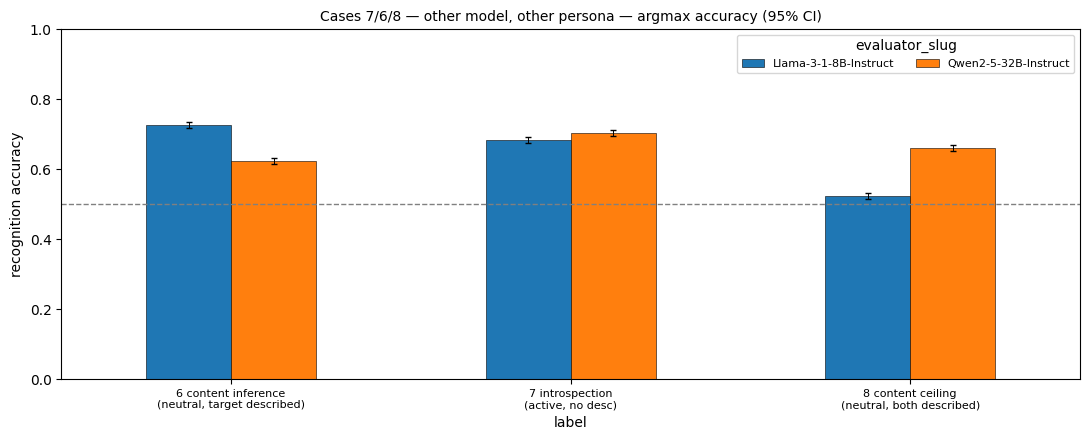

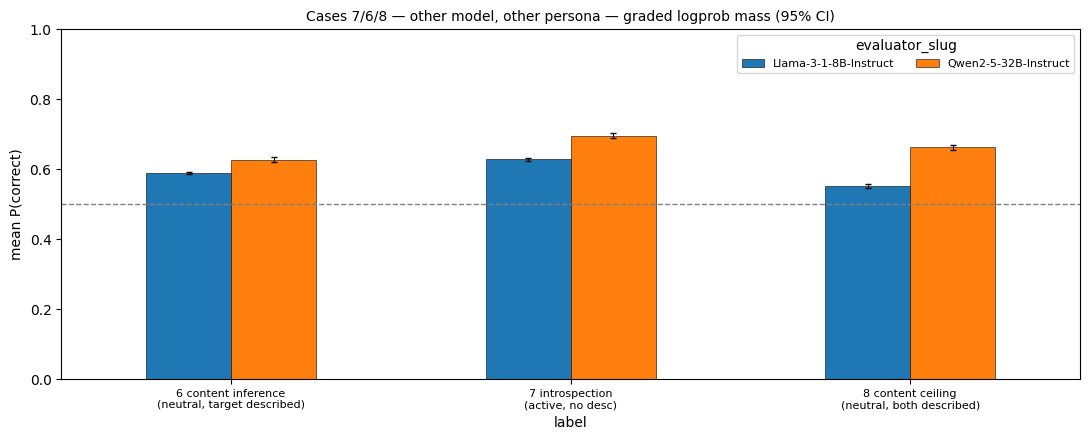

In [11]:
if HAVE_CASES:
    for ft in CASE_FOILS:
        lad = X.case_ladder(df, foil_type=ft, by=("evaluator_slug",))
        if lad.empty:
            print(f"{ft}: no data"); continue
        display(lad[["base_case","evaluator_slug","n","accuracy","ci_lo","ci_hi","p_vs_chance","mean_prob_correct"]].round(3))
        ftl = X.FOIL_LABELS[ft].replace(chr(10)," ")
        B.plot_contrast_by_category(lad, group="evaluator_slug",
            title=f"Cases 7/6/8 — {ftl} — argmax accuracy (95% CI)"); plt.show()
        B.plot_contrast_by_category(lad, group="evaluator_slug", value="mean_prob_correct",
            lo_col="prob_ci_lo", hi_col="prob_ci_hi", ylabel="mean P(correct)",
            title=f"Cases 7/6/8 — {ftl} — graded logprob mass (95% CI)"); plt.show()

### 7b · The ladder by persona category — the verdict

For each evaluator × foil type, the 7/6/8 ladder split by persona category. If **case 7
(introspection)** clears **case 6 (content inference)** specifically in **suppression /
near_twin**, that's the introspection signal; if 7≈6 and both are high only in
calibration/confound, it's style. *(95% CIs.)*

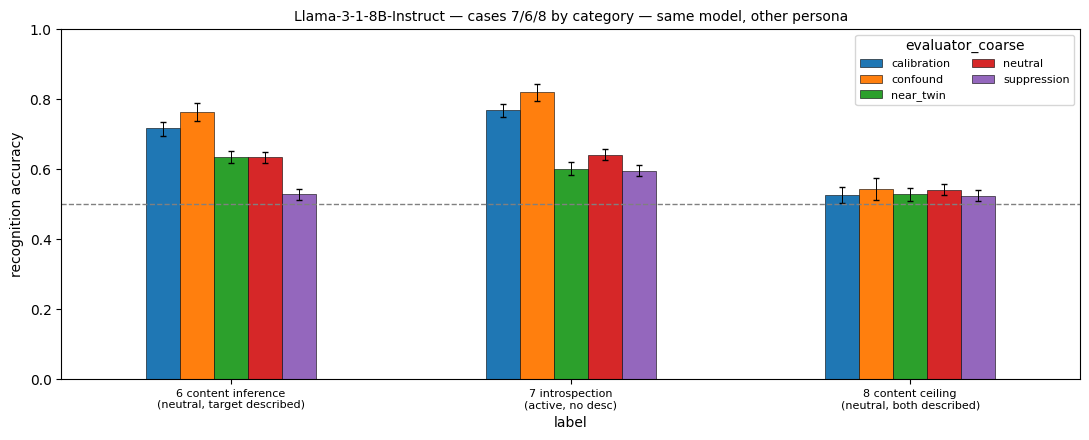

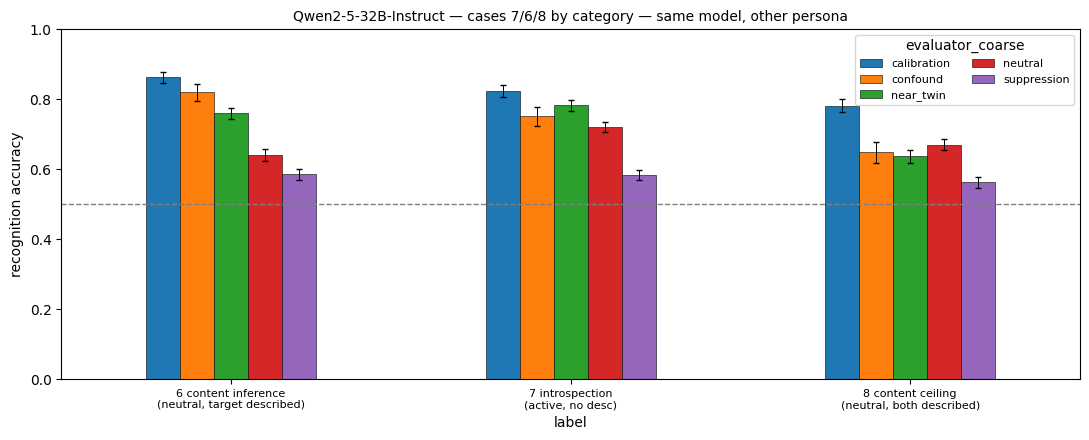

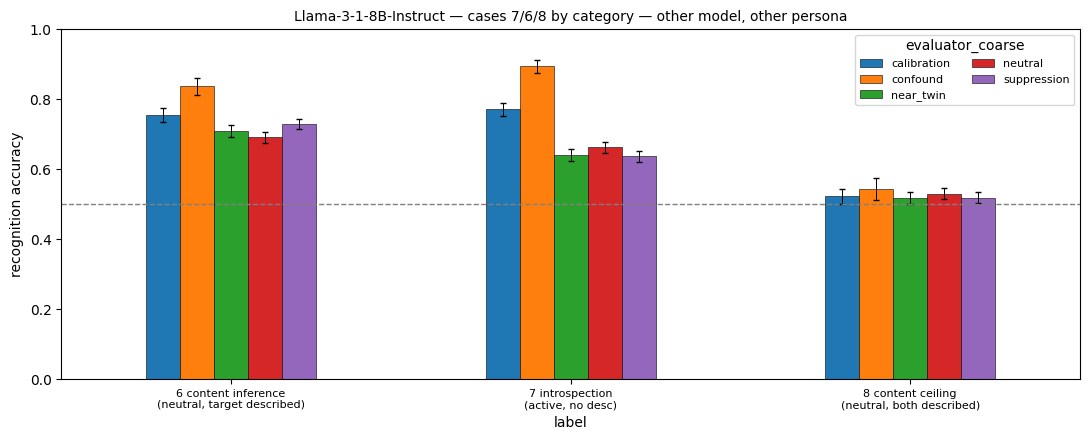

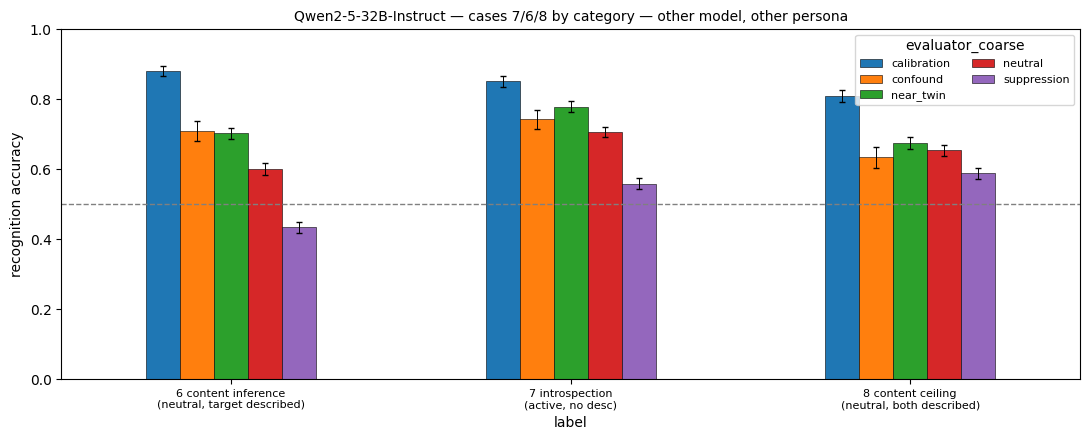

In [12]:
if HAVE_CASES:
    for ft in CASE_FOILS:
        for ev in sorted(df.evaluator_slug.unique()):
            cat = X.case_ladder(df[df.evaluator_slug==ev], foil_type=ft, by=("evaluator_coarse",))
            if cat.empty: continue
            ftl = X.FOIL_LABELS[ft].replace(chr(10)," ")
            B.plot_contrast_by_category(cat, group="evaluator_coarse",
                title=f"{ev} — cases 7/6/8 by category — {ftl}"); plt.show()

### 7c · Introspective surplus (case 7 − case 6)

Active-introspection accuracy minus content-inference accuracy, per evaluator and by
persona category, with a **two-proportion 95% CI**. Bars clearing 0 in **suppression /
near_twin** = introspection beyond what the description alone supports.

=== same model, other persona ===


,evaluator_slug,n_introspect,n_content,acc_introspection,acc_content,acc_surplus,acc_surplus_lo,acc_surplus_hi,label
0,Llama-3-1-8B-Instruct,12960,12960,0.651,0.625,0.026,0.015,0.038,Llama-3-1-8B
1,Qwen2-5-32B-Instruct,12960,12960,0.711,0.697,0.014,0.003,0.025,Qwen2-5-32B


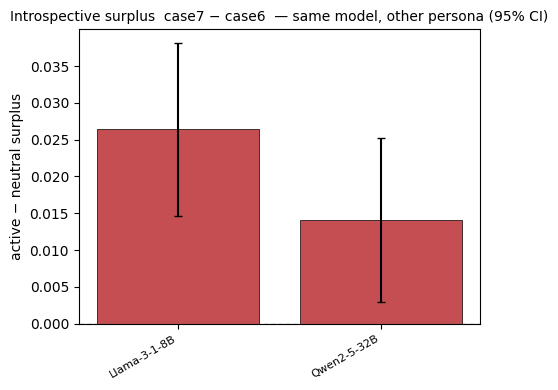

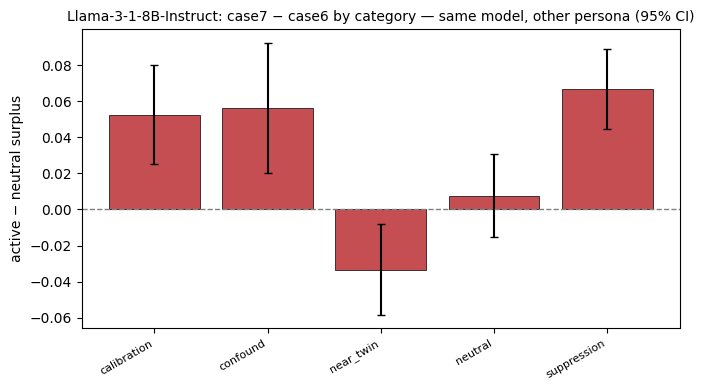

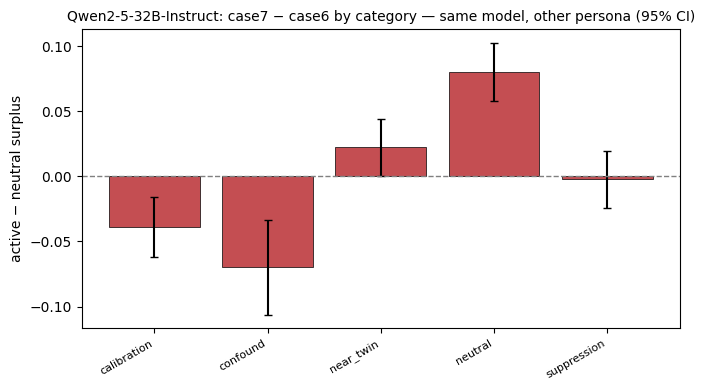

=== other model, other persona ===


,evaluator_slug,n_introspect,n_content,acc_introspection,acc_content,acc_surplus,acc_surplus_lo,acc_surplus_hi,label
0,Llama-3-1-8B-Instruct,12960,12960,0.683,0.727,-0.043,-0.055,-0.032,Llama-3-1-8B
1,Qwen2-5-32B-Instruct,12960,12960,0.703,0.624,0.079,0.068,0.091,Qwen2-5-32B


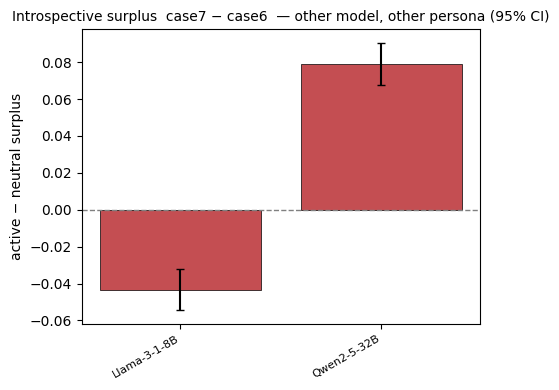

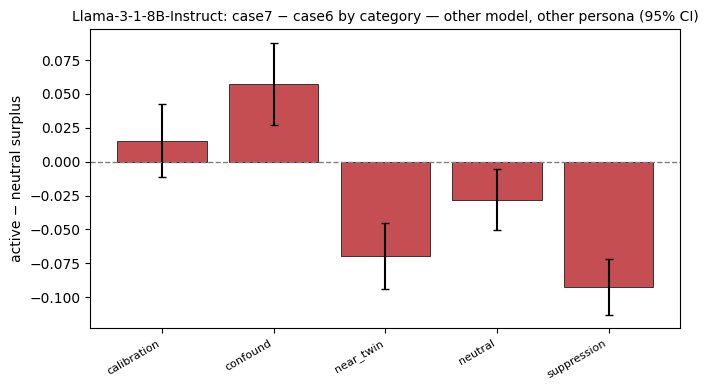

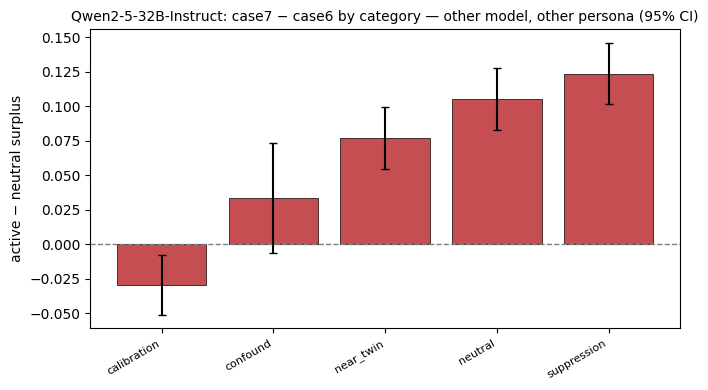

In [13]:
if HAVE_CASES:
    for ft in CASE_FOILS:
        s = X.introspection_surplus(df, foil_type=ft, by=("evaluator_slug",))
        if s.empty:
            print(f"{ft}: need both case7 and case6"); continue
        s["label"] = s.evaluator_slug.str.replace("-Instruct","",regex=False)
        ftl = X.FOIL_LABELS[ft].replace(chr(10)," ")
        print(f"=== {ftl} ==="); display(s.round(3))
        X.plot_surplus(s, title=f"Introspective surplus  case7 − case6  — {ftl} (95% CI)"); plt.show()
        sc = X.introspection_surplus(df, foil_type=ft, by=("evaluator_slug","evaluator_coarse"))
        for ev in sorted(sc.evaluator_slug.unique()):
            t = sc[sc.evaluator_slug==ev].copy(); t["label"] = t.evaluator_coarse
            if not t.empty:
                X.plot_surplus(t, title=f"{ev}: case7 − case6 by category — {ftl} (95% CI)"); plt.show()

### 7d · Master table — base_case × foil_type × evaluator

Every cell's accuracy in one grid (chance = 0.5; each case in its native condition).
Includes case 7 on `diff_model_same_persona` (pure model recognition) for reference.

In [14]:
if HAVE_CASES:
    cases = df[df.base_case.isin(["case6","case7","case8"])].copy()
    # keep each case in its native condition so case7's neutral floor doesn't double-count
    cases = cases[cases.apply(lambda r: r.condition == X.NATIVE_CONDITION.get(r.base_case, r.condition), axis=1)]
    m = X.agg(cases, by=["foil_type","base_case","evaluator_slug"])
    print("Argmax accuracy:")
    display(m.pivot_table(index=["foil_type","base_case"], columns="evaluator_slug",
                          values="accuracy", observed=True).round(3))
    print("Graded mean P(correct):")
    display(m.pivot_table(index=["foil_type","base_case"], columns="evaluator_slug",
                          values="mean_prob_correct", observed=True).round(3))

Argmax accuracy:


evaluator_slug                     Llama-3-1-8B-Instruct  Qwen2-5-32B-Instruct
foil_type               base_case                                             
diff_model_diff_persona case6                      0.727                 0.624
                        case7                      0.683                 0.703
                        case8                      0.524                 0.661
diff_model_same_persona case7                      0.577                 0.456
persona_vs_model        case7                      0.599                 0.715
same_model_diff_persona case6                      0.625                 0.697
                        case7                      0.651                 0.711
                        case8                      0.531                 0.646

Graded mean P(correct):


evaluator_slug                     Llama-3-1-8B-Instruct  Qwen2-5-32B-Instruct
foil_type               base_case                                             
diff_model_diff_persona case6                      0.589                 0.627
                        case7                      0.628                 0.696
                        case8                      0.552                 0.663
diff_model_same_persona case7                      0.553                 0.456
persona_vs_model        case7                      0.565                 0.713
same_model_diff_persona case6                      0.554                 0.690
                        case7                      0.605                 0.701
                        case8                      0.555                 0.648

## 7e · Privileged-access verdict (numeric)

`X.access_verdict(df, foil_type)` — the numeric adjudication (no plots). Primary foil
is **`same_model_diff_persona`** (matched pick-one framing, model held fixed);
`diff_model_diff_persona` is secondary. Four tables per (evaluator × persona category,
**suppression & near_twin first**):

- **ladder** — case7/6/8 accuracy + graded mean + n.
- **surplus** — `case7 − case6` with two-proportion z, Holm-adjusted p (across
  categories), Wald 95% CI, **clustered-bootstrap 95% CI** (resamples
  persona×foil×task clusters — trials aren't independent), and a graded Welch companion.
- **precondition** — is content inference (case6) *at floor*? `clean=True` ⇔ case6 CI
  covers 0.5. Privileged access requires a positive surplus **and** a clean case6.
- **verdict** — PRIVILEGED ACCESS / no access (7≈6) / content-inference / ambiguous.

case 8 (attribute-both) is a ceiling only; never used for the verdict.

In [15]:
for ft in ["same_model_diff_persona", "diff_model_diff_persona"]:
    v = X.access_verdict(df, foil_type=ft, n_boot=1000)
    if not v or v["verdict"].empty:
        print(f"{ft}: need case6 + case7"); continue
    print("="*90); print(f"FOIL: {ft}"); print("="*90)
    print("— ladder (acc + graded, n):")
    display(v["ladder"].round(3))
    print("— introspective surplus case7 − case6 (z, Holm p, Wald CI, clustered-bootstrap CI, graded):")
    display(v["surplus"][["evaluator_slug","evaluator_coarse","surplus","z","p","p_holm",
                          "ci_lo","ci_hi","boot_lo","boot_hi","graded_surplus","graded_p"]].round(3))
    print("— precondition: is content inference (case6) at floor?  clean=True ⇒ CI covers 0.5")
    display(v["precondition"].round(3))
    print("— VERDICT:")
    display(v["verdict"][["evaluator_slug","evaluator_coarse","surplus","boot_lo","boot_hi",
                          "p_holm","case6_clean","verdict"]].round(3))
    print("bootstrap method:", v["surplus"]["boot_method"].iloc[0])

FOIL: same_model_diff_persona
— ladder (acc + graded, n):


,evaluator_slug,evaluator_coarse,acc7,acc6,acc8,graded7,graded6,graded8,n7,n6,n8
0,Llama-3-1-8B-Instruct,suppression,0.596,0.529,0.524,0.558,0.516,0.532,3840,3840,3840
1,Llama-3-1-8B-Instruct,near_twin,0.602,0.635,0.528,0.567,0.558,0.554,2880,2880,2880
2,Llama-3-1-8B-Instruct,confound,0.821,0.765,0.543,0.709,0.578,0.561,960,960,960
3,Llama-3-1-8B-Instruct,calibration,0.769,0.717,0.527,0.717,0.592,0.580,1920,1920,1920
4,Llama-3-1-8B-Instruct,neutral,0.642,0.634,0.542,0.597,0.565,0.566,3360,3360,3360
5,Qwen2-5-32B-Instruct,suppression,0.584,0.586,0.564,0.582,0.585,0.569,3840,3840,3840
6,Qwen2-5-32B-Instruct,near_twin,0.782,0.760,0.636,0.765,0.742,0.642,2880,2880,2880
7,Qwen2-5-32B-Instruct,confound,0.752,0.822,0.649,0.740,0.803,0.655,960,960,960
8,Qwen2-5-32B-Instruct,calibration,0.824,0.863,0.782,0.821,0.856,0.779,1920,1920,1920
9,Qwen2-5-32B-Instruct,neutral,0.721,0.641,0.671,0.703,0.637,0.665,3360,3360,3360


— introspective surplus case7 − case6 (z, Holm p, Wald CI, clustered-bootstrap CI, graded):


,evaluator_slug,evaluator_coarse,surplus,z,p,p_holm,ci_lo,ci_hi,boot_lo,boot_hi,graded_surplus,graded_p
0,Llama-3-1-8B-Instruct,suppression,0.067,5.911,0.000,0.000,0.045,0.089,0.046,0.090,0.042,0.000
1,Llama-3-1-8B-Instruct,near_twin,-0.033,-2.604,0.009,0.018,-0.058,-0.008,-0.055,-0.012,0.009,0.136
2,Llama-3-1-8B-Instruct,confound,0.056,3.040,0.002,0.007,0.020,0.092,0.016,0.097,0.131,0.000
3,Llama-3-1-8B-Instruct,calibration,0.053,3.730,0.000,0.001,0.025,0.080,0.024,0.080,0.125,0.000
4,Llama-3-1-8B-Instruct,neutral,0.008,0.660,0.509,0.509,-0.015,0.031,-0.012,0.025,0.032,0.000
5,Qwen2-5-32B-Instruct,suppression,-0.002,-0.208,0.835,0.835,-0.024,0.020,-0.027,0.024,-0.003,0.721
6,Qwen2-5-32B-Instruct,near_twin,0.022,2.007,0.045,0.089,0.001,0.044,-0.003,0.046,0.023,0.014
7,Qwen2-5-32B-Instruct,confound,-0.070,-3.734,0.000,0.001,-0.106,-0.033,-0.113,-0.030,-0.063,0.000
8,Qwen2-5-32B-Instruct,calibration,-0.039,-3.331,0.001,0.003,-0.062,-0.016,-0.065,-0.015,-0.034,0.001
9,Qwen2-5-32B-Instruct,neutral,0.080,7.066,0.000,0.000,0.058,0.103,0.056,0.103,0.066,0.000


— precondition: is content inference (case6) at floor?  clean=True ⇒ CI covers 0.5


...

— precondition: is content inference (case6) at floor?  clean=True ⇒ CI covers 0.5


,evaluator_slug,evaluator_coarse,acc6,ci_lo,ci_hi,z_vs_chance,p_vs_chance,clean
0,Llama-3-1-8B-Instruct,suppression,0.729,0.715,0.743,28.402,0.0,False
1,Llama-3-1-8B-Instruct,near_twin,0.709,0.693,0.726,22.472,0.0,False
2,Llama-3-1-8B-Instruct,confound,0.838,0.813,0.859,20.914,0.0,False
3,Llama-3-1-8B-Instruct,calibration,0.755,0.735,0.774,22.365,0.0,False
4,Llama-3-1-8B-Instruct,neutral,0.691,0.675,0.706,22.117,0.0,False
5,Qwen2-5-32B-Instruct,suppression,0.435,0.419,0.450,-8.101,0.0,False
6,Qwen2-5-32B-Instruct,near_twin,0.702,0.685,0.719,21.727,0.0,False
7,Qwen2-5-32B-Instruct,confound,0.710,0.681,0.738,13.039,0.0,False
8,Qwen2-5-32B-Instruct,calibration,0.881,0.866,0.895,33.411,0.0,False
9,Qwen2-5-32B-Instruct,neutral,0.601,0.585,0.618,11.731,0.0,False


— VERDICT:


,evaluator_slug,evaluator_coarse,surplus,boot_lo,boot_hi,p_holm,case6_clean,verdict
0,Llama-3-1-8B-Instruct,suppression,-0.092,-0.116,-0.068,0.000,False,content-inference
1,Llama-3-1-8B-Instruct,near_twin,-0.069,-0.093,-0.046,0.000,False,content-inference
2,Llama-3-1-8B-Instruct,confound,0.057,0.022,0.091,0.001,False,ambiguous
3,Llama-3-1-8B-Instruct,calibration,0.016,-0.010,0.043,0.255,False,no access (7≈6)
4,Llama-3-1-8B-Instruct,neutral,-0.028,-0.046,-0.011,0.028,False,content-inference
5,Qwen2-5-32B-Instruct,suppression,0.124,0.100,0.147,0.000,False,ambiguous
6,Qwen2-5-32B-Instruct,near_twin,0.077,0.052,0.101,0.000,False,ambiguous
7,Qwen2-5-32B-Instruct,confound,0.033,-0.017,0.086,0.101,False,no access (7≈6)
8,Qwen2-5-32B-Instruct,calibration,-0.030,-0.055,-0.003,0.014,False,content-inference
9,Qwen2-5-32B-Instruct,neutral,0.105,0.080,0.127,0.000,False,ambiguous


bootstrap method: clustered_bootstrap(clusters=1678, key=evaluator_persona×foil_persona×task_id)


## 7f · Model-vs-persona diagnostic

Per evaluator: **model recognition** (`diff_model_same_persona`, case7),
**persona recognition** (`same_model_diff_persona`, case7), and **persona-anchor**
(`persona_vs_model`). "persona-dominant" = persona recognition & anchor ≫ model
recognition. Interpretation labels: `diff_model_same_persona` is a model-recognition
control; `same_model_diff_persona` is the primary persona / privileged-access
condition; `persona_vs_model` accuracy >0.5 = claims same-persona/other-model text.

,evaluator_slug,model_recognition,persona_recognition,persona_anchor,n_model,n_persona,n_anchor,interpretation
0,Llama-3-1-8B-Instruct,0.577,0.651,0.599,2052,12960,12960,mixed/model-informative
1,Qwen2-5-32B-Instruct,0.456,0.711,0.715,2052,12960,12960,persona-dominant


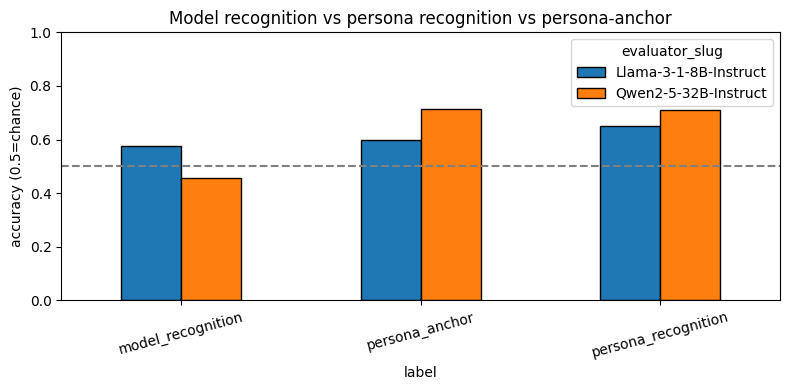

In [16]:
mvp = X.model_vs_persona(df)
display(mvp.round(3))
mp = mvp.melt(id_vars="evaluator_slug",
              value_vars=["model_recognition","persona_recognition","persona_anchor"],
              var_name="metric", value_name="accuracy").rename(columns={"metric":"label"})
import numpy as np
ax = mp.pivot_table(index="label", columns="evaluator_slug", values="accuracy").plot(
    kind="bar", figsize=(8,4), edgecolor="black")
ax.axhline(0.5, ls="--", c="gray"); ax.set_ylim(0,1); ax.set_ylabel("accuracy (0.5=chance)")
ax.set_title("Model recognition vs persona recognition vs persona-anchor"); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

## 8 · Not yet available — cases 13 & 14 (needs a new eval run)

Two requested **framing-matched neutral controls** are **not in the data** (no
`base_case` 13/14 on disk):

- **case 13** — neutral, **both** personas described (full), **pick-one** "which did
  Persona E write?" — a pick-one twin of case 8 (which we only have as attribute-both).
- **case 14** — same, **redacted** descriptions.

These are stronger neutral decoders than case 6 (both-described + framing-matched to
case 7), so `case7 − case13` / `case7 − case14` and `active_minus_best_neutral` can't be
computed yet. They require adding case13/case14 to the cross-model eval and running them.
**Ask if you want me to add + run them.**